# Data Preprocessing for Sentiment Analysis

In [45]:
!pip install pandas nltk wordcloud matplotlib

import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

In [49]:
#files needed
INPUT_FILE  = "kfc_comments_2025_2026.csv"
OUTPUT_FILE = "kfc_preprocessed_sentiment.csv"
WORDCLOUD_FILE = "wordcloud_all_comments.png"

In [60]:
CUSTOM_STOPWORDS = set(stopwords.words("english")).union({
    "kfc", "kfcs",
    "s", "t", "m", "don", "wa", "ha", "im", "ive", "cant", "dont", "ye", "isnt", "oh",
    "doesnt", "didnt", "thats", "theyre", "ur", "lol", "yeah", "ok", "okay", "havent", "op",
    "go", "got", "get", "make", "going", "will", "would", "used", "feel",
    "use", "want", "know", "think", "work", "see", "need", "look", "want", "might",
    "time", "day", "year", "now", "today", "always", "ago", "last",
    "they", "them", "you", "me", "my", "their", "i", "we", "he", "she", "youre", "u", "guys", "man", "person", "someone", "everyone", "anyone", "bro",
    "much", "still", "even", "really", "actually", "every", "everything",
    "thing", "one", "new", "something", "back", "also", "like", "just",
    "good", "bad", "pretty", "nice", "thing", "point", "reason", "stuff",
    "issue", "problem", "month", "week", "hour", "id", "bit", "half", "double", "rest", "way",
    "order", "ordered",
    "well", "people", "place", "said", "say", "way", "will", "would", "went", "sound", "look"
})

In [62]:
#load dataset
df = pd.read_csv(INPUT_FILE)
print(f"Rows loaded: {len(df)}")

df.head()

Rows loaded: 19560


,Post Title,Comment,Upvotes,Timestamp
0,Local KFC refused KFC gift card,Just ask for the store number and politely let...,70,2026-03-25 17:45:25
1,Local KFC refused KFC gift card,Report it to corporate. They don’t get to deci...,34,2026-03-25 17:55:30
2,Local KFC refused KFC gift card,"KFC has enough other issues, why add to custom...",7,2026-03-26 05:01:15
3,Local KFC refused KFC gift card,1 star review (seriously)\n\nMention they won’...,9,2026-03-25 20:58:05
4,Local KFC refused KFC gift card,"Check the fine print. It often will say ""part...",3,2026-03-25 23:39:41


In [63]:
#null and blank
before = len(df)
df = df.dropna(subset=["Comment"])
df = df[df["Comment"].str.strip().astype(bool)]
print(f"Removed {before - len(df)} null/blank rows")
print(f"Remaining: {len(df)}")

Removed 0 null/blank rows
Remaining: 19560


In [65]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"/[ur]/\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_comment(text):
    lemmatizer = WordNetLemmatizer()
    cleaned = clean_text(text)
    tokens = cleaned.split()
    tokens = [t for t in tokens if t not in CUSTOM_STOPWORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

In [66]:
df["Tokenised_Comment"] = df["Comment"].apply(preprocess_comment)

before = len(df)
df = df[df["Tokenised_Comment"].str.strip().astype(bool)]
print(f"Removed {before - len(df)} empty rows")
print(f"Final: {len(df)} rows")

Removed 640 empty rows
Final: 18920 rows


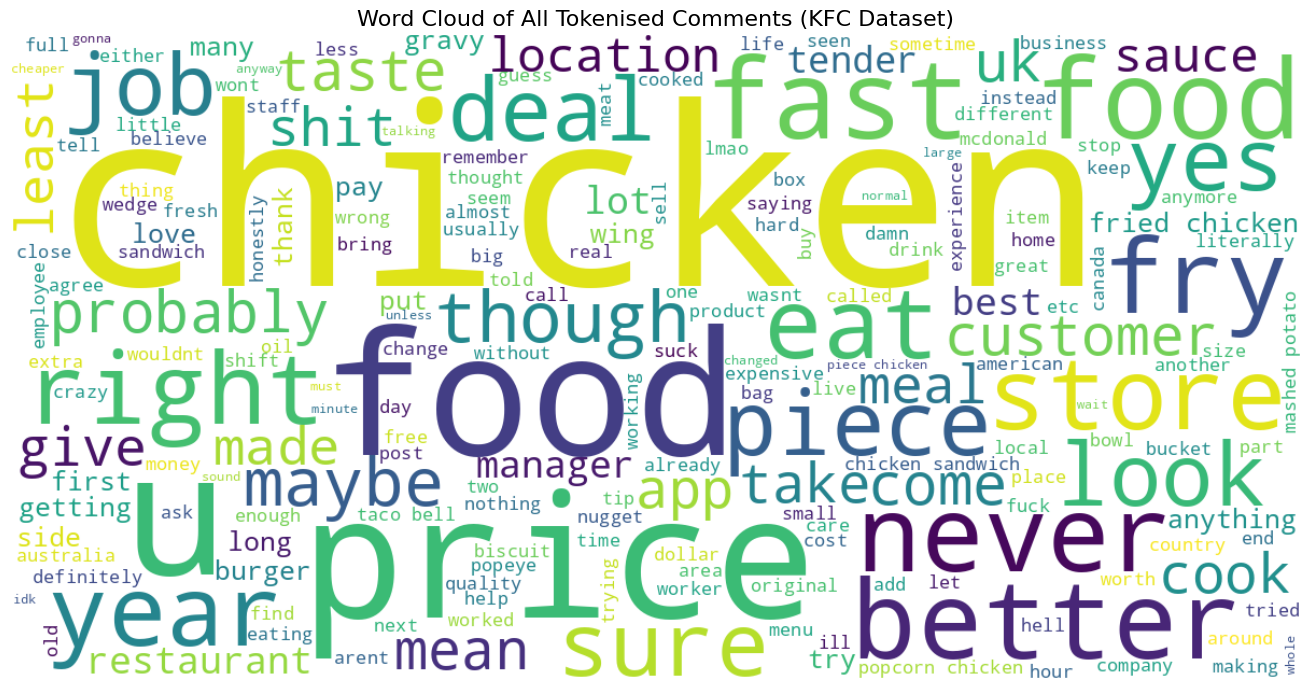

In [67]:
all_words = " ".join(df["Tokenised_Comment"])
wordcloud = WordCloud(
    width=1200, height=600, background_color="white",
    max_words=200, colormap="viridis",
).generate(all_words)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Word Cloud of All Tokenised Comments (KFC Dataset)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.savefig(WORDCLOUD_FILE, dpi=150, bbox_inches="tight")
plt.show()

In [68]:
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print(f"Saved to: {OUTPUT_FILE}")
print(f"Total: {len(df)} comments")

Saved to: kfc_preprocessed_sentiment.csv
Total: 18920 comments
